# Challenge 1: Geodemographic Classification

In this challenge, you will replicate the process of creating a geodemographic classification using the k-means clustering algorithm. Please select any city in the UK except London, Liverpool, or Glasgow. The main goal is to generate a meaningful and informative classification that captures the diversity of areas in your dataset using the census data ( For England, you can try to use the 2021 or 2011 census, and for Scotland, you need to use the 2011 census data) 

1. Define the main goal for the geodemographic classification (marketing, retail and service planning). 
2. Look for census data from the selected city for which you would like to generate the geodemographic classification.
3. The census data at the Output Area OA level. Select multiple topics of at least four topics (socio-demographics, economics, health, and so on). Describe your topic selection accordingly based on the goal of your geodemographic classification. For example, if your geodemographics are related to marketing, Economic variables might be the appropriate selection. 
4. Identify the variables that will be crucial for effectively segmenting neighbourhoods. Evaluate how this choice may impact the classification results, including a DEA analysis.
5. Prepare, adjust or clean the dataset addressing any missing values or outliers that could distort the clustering results.
6. Include standardisation between areas and variables. Make an appropriate analysis and adjust the variable selection accordingly for any multicollinearity.
7. Utilize the k-means clustering algorithm to create a classification based on the selected variables.
8. Define the optimum number of clusters (i.e., using the Elblow method). Experiment with different values of k.
9. Evaluate your cluster groups (e.g., using PCA) and interpret your cluster centres. Describe your results and repeat the process to adjust the variable selection and cluster groups to provide more meaningful results for your geodemographic goal. Interpret the characteristics of each cluster. What demographic patterns or similarities are prevalent within each group?
10. Map the final cluster groups
11. Finish the analysis by naming the final clusters and plotting a final map that includes the census values and the provided names.
12. Finally, acknowledge the subjective nature of classification and make analytical decisions to produce an optimum classification for your specific purpose. Reflect on the challenges and insights gained during the classification process. Ensure you document your analytical decisions and the rationale behind any important decision. Once your geodemographics are constructed, describe the potential use cases for the geodemographic classification you have built based on your initial goal.

In [ ]:
#defining the main goal for the geodemographic classification

I will be examining data for the city of Brigthton and Hove from a marketing perspective using data from the 2021 Census for England and Wales.

**Study area**: Brighton and Hove
**Geography (spatial units)** Output Areas 
**Dataset**: 2021 United Kingdom Census 

**Census Variables Used** - 
- Age structure
- Economic activity
- Ethnicity
- General Health
- Highest Level of Educational Qualification
- Industry
- Living Arrangement
- Marital and civil partnership status
- Religion
- Sex

Reference: ONS (2021). Census - Office for National Statistics. [online] Ons.gov.uk. Available at: https://www.ons.gov.uk/census.

In [ ]:
#identifying variables to help with a marketing analysis 

In [ ]:
#preparing the variables for analysis

In [59]:
#exploring one variable for analysis - ethnicity to look at how the columns are
import pandas as pd
import geopandas as gpd
age_directory = "data/lab_raw_data/agebrighton.csv"
age = gpd.read_file(age_directory)
age.head()

,Output Areas,Age (6 categories) Code,Age (6 categories),Observation Age
0,E00085001,1,Aged 15 years and under,13
1,E00085001,2,Aged 16 to 24 years,37
2,E00085001,3,Aged 25 to 34 years,58
3,E00085001,4,Aged 35 to 49 years,71
4,E00085001,5,Aged 50 to 64 years,40


In [60]:
#reading in selected raw census data (csv files)
import pandas as pd
import os

csv_directory = "data/lab_raw_data"

csv_files = [file for file in os.listdir(csv_directory) if file.endswith(".csv")]

# an empty DataFrame to store the merged data
merged_data = pd.DataFrame()

In [61]:
#merging the csv files
for csv_file in csv_files:
    csv_path = os.path.join(csv_directory, csv_file)
    df_csv = pd.read_csv(csv_path, low_memory=False)
    merged_data = pd.concat([merged_data, df_csv], axis=1)

merged_data.to_csv("data/lab_raw_data/merged_lab_data.csv", index=False)

In [62]:
#checking out first few columns of merged variables
merged_data.head()

,Output Areas,Age (6 categories) Code,Age (6 categories),Observation Age,OA,Age,Age_Obs,Economic_status,Economic_Obs,Ethnic_group,...,Observation Religion.1,Sex (2 categories) Code.1,Sex (2 categories).1,Observation Sex.1,Religion (10 categories) Code,Religion (10 categories),Observation Religion,Sex (2 categories) Code,Sex (2 categories),Observation Sex
0,E00085001,1.0,Aged 15 years and under,13.0,E00085001,Aged 15 years and under,13.0,Does not apply,13.0,Does not apply,...,0.0,1.0,Female,118.0,-8.0,Does not apply,0.0,1.0,Female,118.0
1,E00085001,2.0,Aged 16 to 24 years,37.0,E00085001,Aged 16 to 24 years,37.0,Economically active (excluding full-time stude...,133.0,"Asian, Asian British or Asian Welsh: Bangladeshi",...,127.0,2.0,Male,121.0,1.0,No religion,127.0,2.0,Male,121.0
2,E00085001,3.0,Aged 25 to 34 years,58.0,E00085001,Aged 25 to 34 years,58.0,Economically active (excluding full-time stude...,7.0,"Asian, Asian British or Asian Welsh: Chinese",...,59.0,1.0,Female,181.0,2.0,Christian,59.0,1.0,Female,181.0
3,E00085001,4.0,Aged 35 to 49 years,71.0,E00085001,Aged 35 to 49 years,71.0,Economically active and a full-time student: I...,10.0,"Asian, Asian British or Asian Welsh: Indian",...,1.0,2.0,Male,145.0,3.0,Buddhist,1.0,2.0,Male,145.0
4,E00085001,5.0,Aged 50 to 64 years,40.0,E00085001,Aged 50 to 64 years,40.0,Economically active and a full-time student: U...,7.0,"Asian, Asian British or Asian Welsh: Pakistani",...,3.0,1.0,Female,123.0,4.0,Hindu,3.0,1.0,Female,123.0


In [63]:
#renaming categories so that data manipulation is easier
short_column_names = {
    'Output Areas': 'OA',
    'Age (6 categories)': 'Age',
    'Observation Age': 'Age_Obs',
    'Economic activity status (7 categories)': 'Economic_status',
    'Observation Economic activity status': 'Economic_Obs',
    'Ethnic group (20 categories)': 'Ethnic_group',
    'Observation Ethnic group': 'Ethnic_Obs',
    'General health (4 categories)': 'Health',
    'Observation General health': 'Health_Obs',
    'Highest level of qualification (7 categories)': 'Highest_qual',
    'Observation Highest level of qualification': 'Highest_Obs',
    'Industry (current) (9 categories)': 'Industry',
    'Observation Industry (current)': 'Industry_Obs',
    'Living arrangements (11 categories)': 'Living_arr',
    'Observation Living arrangements': 'Living_Obs',
    'Marital and civil partnership status (6 categories)': 'Marital_stat',
    'Observation Marital and civil partnership status': 'Marital_Obs',
    'Religion (10 categories)': 'Religion',
    'Observation Religion': 'Religion_Obs',
    'Sex (2 categories)': 'Sex',
    'Observation Sex': 'Sex_Obs'
}

brighton_census_data = merged_data.rename(columns=short_column_names)

In [64]:
#reviewing new names of columns
brighton_census_data.head()

,OA,Age (6 categories) Code,Age,Age_Obs,OA,Age,Age_Obs,Economic_status,Economic_Obs,Ethnic_group,...,Observation Religion.1,Sex (2 categories) Code.1,Sex (2 categories).1,Observation Sex.1,Religion (10 categories) Code,Religion,Religion_Obs,Sex (2 categories) Code,Sex,Sex_Obs
0,E00085001,1.0,Aged 15 years and under,13.0,E00085001,Aged 15 years and under,13.0,Does not apply,13.0,Does not apply,...,0.0,1.0,Female,118.0,-8.0,Does not apply,0.0,1.0,Female,118.0
1,E00085001,2.0,Aged 16 to 24 years,37.0,E00085001,Aged 16 to 24 years,37.0,Economically active (excluding full-time stude...,133.0,"Asian, Asian British or Asian Welsh: Bangladeshi",...,127.0,2.0,Male,121.0,1.0,No religion,127.0,2.0,Male,121.0
2,E00085001,3.0,Aged 25 to 34 years,58.0,E00085001,Aged 25 to 34 years,58.0,Economically active (excluding full-time stude...,7.0,"Asian, Asian British or Asian Welsh: Chinese",...,59.0,1.0,Female,181.0,2.0,Christian,59.0,1.0,Female,181.0
3,E00085001,4.0,Aged 35 to 49 years,71.0,E00085001,Aged 35 to 49 years,71.0,Economically active and a full-time student: I...,10.0,"Asian, Asian British or Asian Welsh: Indian",...,1.0,2.0,Male,145.0,3.0,Buddhist,1.0,2.0,Male,145.0
4,E00085001,5.0,Aged 50 to 64 years,40.0,E00085001,Aged 50 to 64 years,40.0,Economically active and a full-time student: U...,7.0,"Asian, Asian British or Asian Welsh: Pakistani",...,3.0,1.0,Female,123.0,4.0,Hindu,3.0,1.0,Female,123.0


In [65]:
#cleaning up the merged variables dataset for better visibility during data analysis - clearing out irrelevant columns
keep_cols= [
    'OA',
    'Age',
    'Age_Obs',
    'Economic_status',
    'Economic_Obs',
    'Ethnic_group',
    'Ethnic_Obs',
    'Health',
    'Health_Obs',
    'Highest_qual',
    'Highest_Obs',
    'Industry',
    'Industry_Obs',
    'Living_arr',
    'Living_Obs',
    'Marital_stat',
    'Marital_Obs',
    'Religion',
    'Religion_Obs',
    'Sex',
    'Sex_Obs'
]
    
brighton_census_data = brighton_census_data[keep_cols]

In [66]:
#checking the new table
brighton_census_data.head()

,OA,OA,OA,OA,Age,Age,Age,Age,Age_Obs,Age_Obs,...,Religion_Obs,Religion_Obs,Sex,Sex,Sex,Sex,Sex_Obs,Sex_Obs,Sex_Obs,Sex_Obs
0,E00085001,E00085001,E00085001,E00085001,Aged 15 years and under,Aged 15 years and under,Aged 15 years and under,Aged 15 years and under,13.0,13.0,...,0.0,0.0,Female,Female,Female,Female,118.0,118.0,118.0,118.0
1,E00085001,E00085001,E00085001,E00085001,Aged 16 to 24 years,Aged 16 to 24 years,Aged 16 to 24 years,Aged 16 to 24 years,37.0,37.0,...,127.0,127.0,Male,Male,Male,Male,121.0,121.0,121.0,121.0
2,E00085001,E00085001,E00085001,E00085001,Aged 25 to 34 years,Aged 25 to 34 years,Aged 25 to 34 years,Aged 25 to 34 years,58.0,58.0,...,59.0,59.0,Female,Female,Female,Female,181.0,181.0,181.0,181.0
3,E00085001,E00085001,E00085001,E00085001,Aged 35 to 49 years,Aged 35 to 49 years,Aged 35 to 49 years,Aged 35 to 49 years,71.0,71.0,...,1.0,1.0,Male,Male,Male,Male,145.0,145.0,145.0,145.0
4,E00085001,E00085001,E00085001,E00085001,Aged 50 to 64 years,Aged 50 to 64 years,Aged 50 to 64 years,Aged 50 to 64 years,40.0,40.0,...,3.0,3.0,Female,Female,Female,Female,123.0,123.0,123.0,123.0


In [67]:
#eliminating any duplicates in the data
brighton_census_data = brighton_census_data.loc[:, ~brighton_census_data.columns.duplicated()]
brighton_census_data.columns.tolist()

['OA',
 'Age',
 'Age_Obs',
 'Economic_status',
 'Economic_Obs',
 'Ethnic_group',
 'Ethnic_Obs',
 'Health',
 'Health_Obs',
 'Highest_qual',
 'Highest_Obs',
 'Industry',
 'Industry_Obs',
 'Living_arr',
 'Living_Obs',
 'Marital_stat',
 'Marital_Obs',
 'Religion',
 'Religion_Obs',
 'Sex',
 'Sex_Obs']

In [68]:
#checking that duplicates are eliminated
brighton_census_data.head()

,OA,Age,Age_Obs,Economic_status,Economic_Obs,Ethnic_group,Ethnic_Obs,Health,Health_Obs,Highest_qual,...,Industry,Industry_Obs,Living_arr,Living_Obs,Marital_stat,Marital_Obs,Religion,Religion_Obs,Sex,Sex_Obs
0,E00085001,Aged 15 years and under,13.0,Does not apply,13.0,Does not apply,0,Does not apply,0.0,Does not apply,...,Does not apply,96.0,Does not apply,13.0,Does not apply,13.0,Does not apply,0.0,Female,118.0
1,E00085001,Aged 16 to 24 years,37.0,Economically active (excluding full-time stude...,133.0,"Asian, Asian British or Asian Welsh: Bangladeshi",0,Very good or good health,192.0,No qualifications,...,"A, B, D, E Agriculture, energy and water",1.0,Living in an opposite-sex couple: Married or i...,40.0,Never married and never registered a civil par...,145.0,No religion,127.0,Male,121.0
2,E00085001,Aged 25 to 34 years,58.0,Economically active (excluding full-time stude...,7.0,"Asian, Asian British or Asian Welsh: Chinese",2,Fair health,34.0,Level 1 and entry level qualifications: 1 to 4...,...,C Manufacturing,8.0,Living in a same-sex couple: Married or in a c...,4.0,Married or in a registered civil partnership,44.0,Christian,59.0,Female,181.0
3,E00085001,Aged 35 to 49 years,71.0,Economically active and a full-time student: I...,10.0,"Asian, Asian British or Asian Welsh: Indian",5,Bad or very bad health,13.0,Level 2 qualifications: 5 or more GCSEs (A* to...,...,F Construction,5.0,"Living in a couple: Separated, but still marri...",0.0,"Separated, but still legally married or still ...",8.0,Buddhist,1.0,Male,145.0
4,E00085001,Aged 50 to 64 years,40.0,Economically active and a full-time student: U...,7.0,"Asian, Asian British or Asian Welsh: Pakistani",2,Does not apply,0.0,Level 3 qualifications: 2 or more A levels or ...,...,"G, I Distribution, hotels and restaurants",24.0,Living in an opposite-sex couple: Cohabiting,36.0,Divorced or civil partnership dissolved,26.0,Hindu,3.0,Female,123.0


In [69]:
brighton_census_data.columns

Index(['OA', 'Age', 'Age_Obs', 'Economic_status', 'Economic_Obs',
       'Ethnic_group', 'Ethnic_Obs', 'Health', 'Health_Obs', 'Highest_qual',
       'Highest_Obs', 'Industry', 'Industry_Obs', 'Living_arr', 'Living_Obs',
       'Marital_stat', 'Marital_Obs', 'Religion', 'Religion_Obs', 'Sex',
       'Sex_Obs'],
      dtype='object')

In [70]:
#saving this new dataframe, with census data organised into one complete table, as a new csv
brighton_census_data.to_csv("data/lab_raw_data/brighton_census_data.csv", index=False)

In [71]:
#merging the census data with the output area shapefile for Brighton and Hove
import pandas as pd
import geopandas as gpd

shp_path = "data/lab_raw_data/brighton_hove_output_areas.shp"
gdf = gpd.read_file(shp_path)

csv_path = "data/lab_raw_data/brighton_census_data.csv"
csv_data = pd.read_csv(csv_path, low_memory=False)

# merging the GeoDataFrame with the DataFrame based on the oa_code
merged_data = gdf.merge(csv_data, left_on='OA21CD', right_on='OA', how='left')
#saving it as a shapefile
merged_data.to_file('data/lab_raw_data/brighton_census_data.shp', index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_5036\2359341316.py:14: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged_data.to_file('data/lab_raw_data/brighton_census_data.shp', index=False)
C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Economic_status' to 'Economic_s'
  ogr_write(
C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Economic_Obs' to 'Economic_O'
  ogr_write(
C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Ethnic_group' to 'Ethnic_gro'
  ogr_write(
C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Highest_qual' to 'Highest_qu'
  ogr_write(
C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Highest_Obs' to 'H

In [72]:
gdf.head()

,OA21CD,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516..."
1,E00085002,E01016852,Brighton and Hove 026B,None,529632,104503,50.8256,-0.16081,63969c3d-b4c4-4f6c-9523-b9f826a11c3c,"POLYGON ((529600 104563, 529702.871 104531.025..."
2,E00085003,E01016850,Brighton and Hove 029A,None,529936,104439,50.8249,-0.15652,b769cd64-c3c9-4bc3-9968-f1f58e718ea1,"POLYGON ((530000.031 104482.116, 530016.999 10..."
3,E00085005,E01016850,Brighton and Hove 029A,None,529837,104310,50.8238,-0.15797,7a103ec3-7492-4a98-ad27-a24d13a7c016,"POLYGON ((529898.327 104377.927, 529871.691 10..."
4,E00085006,E01016853,Brighton and Hove 026C,None,529485,104756,50.8279,-0.16281,f1121dba-7400-46d4-8d73-90fcecaac265,"POLYGON ((529491.999 104828.11, 529561.05 1048..."


In [73]:
csv_data.head()

,OA,Age,Age_Obs,Economic_status,Economic_Obs,Ethnic_group,Ethnic_Obs,Health,Health_Obs,Highest_qual,...,Industry,Industry_Obs,Living_arr,Living_Obs,Marital_stat,Marital_Obs,Religion,Religion_Obs,Sex,Sex_Obs
0,E00085001,Aged 15 years and under,13.0,Does not apply,13.0,Does not apply,0,Does not apply,0.0,Does not apply,...,Does not apply,96.0,Does not apply,13.0,Does not apply,13.0,Does not apply,0.0,Female,118.0
1,E00085001,Aged 16 to 24 years,37.0,Economically active (excluding full-time stude...,133.0,"Asian, Asian British or Asian Welsh: Bangladeshi",0,Very good or good health,192.0,No qualifications,...,"A, B, D, E Agriculture, energy and water",1.0,Living in an opposite-sex couple: Married or i...,40.0,Never married and never registered a civil par...,145.0,No religion,127.0,Male,121.0
2,E00085001,Aged 25 to 34 years,58.0,Economically active (excluding full-time stude...,7.0,"Asian, Asian British or Asian Welsh: Chinese",2,Fair health,34.0,Level 1 and entry level qualifications: 1 to 4...,...,C Manufacturing,8.0,Living in a same-sex couple: Married or in a c...,4.0,Married or in a registered civil partnership,44.0,Christian,59.0,Female,181.0
3,E00085001,Aged 35 to 49 years,71.0,Economically active and a full-time student: I...,10.0,"Asian, Asian British or Asian Welsh: Indian",5,Bad or very bad health,13.0,Level 2 qualifications: 5 or more GCSEs (A* to...,...,F Construction,5.0,"Living in a couple: Separated, but still marri...",0.0,"Separated, but still legally married or still ...",8.0,Buddhist,1.0,Male,145.0
4,E00085001,Aged 50 to 64 years,40.0,Economically active and a full-time student: U...,7.0,"Asian, Asian British or Asian Welsh: Pakistani",2,Does not apply,0.0,Level 3 qualifications: 2 or more A levels or ...,...,"G, I Distribution, hotels and restaurants",24.0,Living in an opposite-sex couple: Cohabiting,36.0,Divorced or civil partnership dissolved,26.0,Hindu,3.0,Female,123.0


In [74]:
list(merged_data.columns)

['OA21CD',
 'LSOA21CD',
 'LSOA21NM',
 'LSOA21NMW',
 'BNG_E',
 'BNG_N',
 'LAT',
 'LONG',
 'GlobalID',
 'geometry',
 'OA',
 'Age',
 'Age_Obs',
 'Economic_status',
 'Economic_Obs',
 'Ethnic_group',
 'Ethnic_Obs',
 'Health',
 'Health_Obs',
 'Highest_qual',
 'Highest_Obs',
 'Industry',
 'Industry_Obs',
 'Living_arr',
 'Living_Obs',
 'Marital_stat',
 'Marital_Obs',
 'Religion',
 'Religion_Obs',
 'Sex',
 'Sex_Obs']

In [75]:
merged_data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5616 entries, 0 to 5615
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   OA21CD           5616 non-null   object  
 1   LSOA21CD         5616 non-null   object  
 2   LSOA21NM         5616 non-null   object  
 3   LSOA21NMW        0 non-null      object  
 4   BNG_E            5616 non-null   int64   
 5   BNG_N            5616 non-null   int64   
 6   LAT              5616 non-null   float64 
 7   LONG             5616 non-null   float64 
 8   GlobalID         5616 non-null   object  
 9   geometry         5616 non-null   geometry
 10  OA               5616 non-null   object  
 11  Age              5616 non-null   object  
 12  Age_Obs          5616 non-null   float64 
 13  Economic_status  5616 non-null   object  
 14  Economic_Obs     5616 non-null   float64 
 15  Ethnic_group     5616 non-null   object  
 16  Ethnic_Obs       5616 non-null   i

In [76]:
merged_data.shape

(5616, 31)

In [77]:
merged_data.head()

,OA21CD,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry,...,Industry,Industry_Obs,Living_arr,Living_Obs,Marital_stat,Marital_Obs,Religion,Religion_Obs,Sex,Sex_Obs
0,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,Does not apply,96.0,Does not apply,13.0,Does not apply,13.0,Does not apply,0.0,Female,118.0
1,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,"A, B, D, E Agriculture, energy and water",1.0,Living in an opposite-sex couple: Married or i...,40.0,Never married and never registered a civil par...,145.0,No religion,127.0,Male,121.0
2,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,C Manufacturing,8.0,Living in a same-sex couple: Married or in a c...,4.0,Married or in a registered civil partnership,44.0,Christian,59.0,Female,181.0
3,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,F Construction,5.0,"Living in a couple: Separated, but still marri...",0.0,"Separated, but still legally married or still ...",8.0,Buddhist,1.0,Male,145.0
4,E00085001,E01016852,Brighton and Hove 026B,None,529776,104607,50.8265,-0.15873,f344c9c4-ab5e-4908-83d8-6afcc7ee0b17,"POLYGON ((529813.436 104652.842, 529785 104516...",...,"G, I Distribution, hotels and restaurants",24.0,Living in an opposite-sex couple: Cohabiting,36.0,Divorced or civil partnership dissolved,26.0,Hindu,3.0,Female,123.0


In [ ]:
merged_data.plot()

In [ ]:
merged_data.explore()

In [ ]:
#Descriptive Analysis - DE
#before analysing my data I need to pivot the data in order to be able to analyse it:

In [ ]:
#pivoting the data


In [84]:
merged_data['Religion'].value_counts().get('Hindu', 0)

np.int64(562)

KeyError: 'Aged 25 to 34 years'

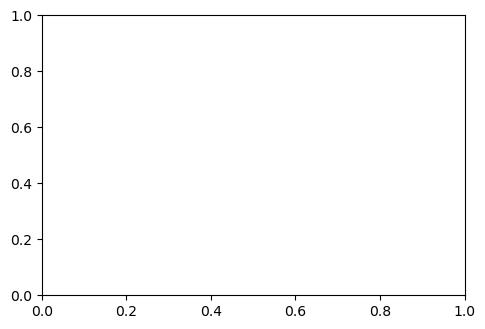

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

attributes_to_plot = ['Aged 25 to 34 years',
                      'Economically active ...',
                      'F Construction',
                      'Male']

plt.figure(figsize=(12, 8))

for i, attribute in enumerate(attributes_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.violinplot(x=merged_data[attribute])
    plt.title(attribute)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

KeyError: 'Aged 25 to 34 years'

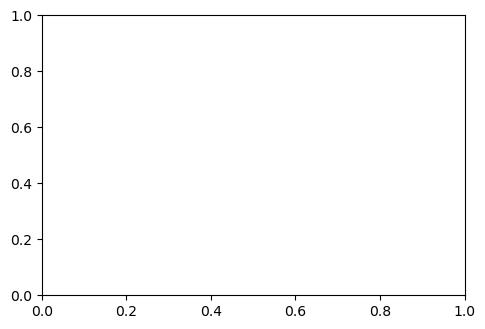

In [90]:
import matplotlib.pyplot as plt

attributes_to_plot = ['Aged 25 to 34 years',
                      'Economically active ...',
                      'F Construction',
                      'Male']

plt.figure(figsize=(12, 8))

for i, attribute in enumerate(attributes_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(merged_data[attribute].astype(str), kde=True)
    plt.title(attribute)

plt.tight_layout()
plt.show()